In [1]:
%matplotlib inline
import pandas

In [44]:
df = pandas.read_csv(
    'behavior data/4072_0623/active_1.txt',
    delimiter='\t',
    skiprows=6,
    usecols=list(range(11))[2:],
    names=[
#        'participant_name',
#        'participant_ID',
        'session_type',
        'event_name',
        '???',
        'response',
        'key',
        'mouse_X',
        'mouse_Y',
        'error_code',
        'reaction_time',
    ]
)
df = df[df.response.notna()]
df.head()

,session_type,event_name,???,response,key,mouse_X,mouse_Y,error_code,reaction_time
5,6,response,NaN,Left,Pressed,42.0,130.0,C,8620
11,7,response,NaN,Left,Pressed,42.0,130.0,C,8373
17,3,response,NaN,Left,Pressed,42.0,130.0,C,8501
23,9,response,NaN,Left,Pressed,42.0,130.0,C,8205
29,5,response,NaN,Left,Pressed,42.0,130.0,C,8357


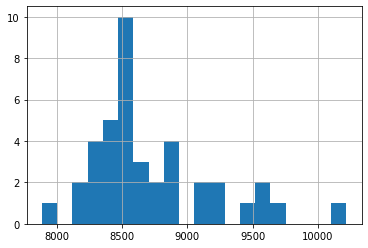

In [45]:
df.reaction_time.hist(bins=20)

In [61]:
df.loc[(df.session_type<=5) & (df.response=='Left'),'outcome'] = 'Hit'
df.loc[(df.session_type<=5) & (df.response=='Right'),'outcome'] = 'Miss'
df.loc[(df.session_type>5) & (df.response=='Left'),'outcome'] = 'False alarm'
df.loc[(df.session_type>5) & (df.response=='Right'),'outcome'] = 'Correct reject'
df.outcome.value_counts()

False alarm       17
Hit               15
Miss               5
Correct reject     3
Name: outcome, dtype: int64

In [ ]:
import seaborn
g = seaborn.FacetGrid(df, hue='outcome')
g.map(seaborn.distplot, 'response', label='outcome')